# DL Spring 2026 — Text-to-SVG LoRA Fine-tuning
**NYU Tandon | CS-GY 9223 / ECE-GY 7123**

This notebook:
1. Installs dependencies
2. Loads and cleans the competition training data
3. Fine-tunes Qwen2.5-Coder-1.5B-Instruct with QLoRA
4. Runs batched inference on test.csv
5. Validates and exports submission.csv

**AI Tooling Disclosure:** Claude (Anthropic) used for code scaffolding and debugging.

## 1. Install Dependencies

In [8]:
from google.colab import drive, files
drive.mount("/content/drive")

import os, shutil

# Create the folder in Drive
os.makedirs("/content/drive/MyDrive/svg_data", exist_ok=True)

# Check if files already exist in Drive
if not os.path.exists("/content/drive/MyDrive/svg_data/train.csv"):
    print("Upload train.csv and test.csv now...")
    uploaded = files.upload()  # select both files
    shutil.copy("train.csv", "/content/drive/MyDrive/svg_data/train.csv")
    shutil.copy("test.csv", "/content/drive/MyDrive/svg_data/test.csv")
    print("Saved to Drive!")
else:
    print("Files already in Drive, skipping upload.")

print("train.csv exists:", os.path.exists("/content/drive/MyDrive/svg_data/train.csv"))
print("test.csv exists:", os.path.exists("/content/drive/MyDrive/svg_data/test.csv"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload train.csv and test.csv now...


Saving train.csv to train.csv
Saving test.csv to test.csv
Saved to Drive!
train.csv exists: True
test.csv exists: True


In [9]:
# Run once in Kaggle/Colab — comment out if packages are already installed
!pip install -q unsloth datasets trl transformers accelerate peft bitsandbytes pandas lxml cairosvg

## 2. Imports & Seeds

In [10]:
import os
import re
import time
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


## 3. Config

All hyperparameters in one place. Tune here, not inline.

In [11]:
CONFIG = {
    # --- Model ---
    # Qwen2.5-Coder is better than generic Qwen for structured code like SVG.
    # 1.5B fits comfortably in 16GB VRAM with 4-bit quant.
    "model_name": "Qwen/Qwen2.5-Coder-1.5B-Instruct",
    # "max_seq_length": 2048,  # SVGs can be long; 2048 covers 99%+ of training samples

    # --- LoRA ---
    # r=32 gives more capacity than the starter's r=16; alpha=64 keeps effective lr scale at 2.0
    "lora_r": 32,
    "lora_alpha": 64,
    "lora_dropout": 0.05,

    # --- Training ---
    "learning_rate": 2e-4,
    "num_train_epochs": 2,           # 2 epochs on 50k is enough; more risks overfitting
    "per_device_train_batch_size": 4,   # was 1
    "gradient_accumulation_steps": 4,   # was 16, effective batch still = 16
    "max_seq_length": 2048,             # was 1024, back to full length
    "inference_batch_size": 16,         # was 4, faster inference        # reducing inference batch for 1st run
    "weight_decay": 0.01,
    "max_grad_norm": 0.3,
    "logging_steps": 25,
    "eval_steps": 200,
    "save_steps": 400,
    "eval_size": 0.02,               # 2% held out for validation

    # --- Data ---
    # Set to None to use all 50k rows. Reduce to 20000 for a fast first run.
    "max_train_samples": 5000,
    "min_svg_length": 50,            # Filter out garbage SVGs that are too short
    "max_svg_length": 16000,         # Competition hard limit (per dataset description)
    "min_prompt_length": 5,          # Filter out empty/garbage prompts

    # --- Inference ---
    "max_new_tokens": 700,           # SVGs average ~500 tokens; 700 gives headroom
    # "inference_batch_size": 8,       # Batched inference — tune based on VRAM
    "temperature": 0.3,              # Low temp for more deterministic, valid SVG
    "top_p": 0.9,
    "repetition_penalty": 1.1,

    # --- Paths ---
    # Kaggle paths — update if running locally
    "train_path": "/content/drive/MyDrive/svg_data/train.csv",
    "test_path": "/content/drive/MyDrive/svg_data/test.csv",
    "output_dir": "/content/svg_lora_output",
    "submission_path": "/content/submission.csv",
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Config loaded.")
CONFIG

Config loaded.


{'model_name': 'Qwen/Qwen2.5-Coder-1.5B-Instruct',
 'lora_r': 32,
 'lora_alpha': 64,
 'lora_dropout': 0.05,
 'learning_rate': 0.0002,
 'num_train_epochs': 2,
 'per_device_train_batch_size': 4,
 'gradient_accumulation_steps': 4,
 'max_seq_length': 2048,
 'inference_batch_size': 16,
 'weight_decay': 0.01,
 'max_grad_norm': 0.3,
 'logging_steps': 25,
 'eval_steps': 200,
 'save_steps': 400,
 'eval_size': 0.02,
 'max_train_samples': 5000,
 'min_svg_length': 50,
 'max_svg_length': 16000,
 'min_prompt_length': 5,
 'max_new_tokens': 700,
 'temperature': 0.3,
 'top_p': 0.9,
 'repetition_penalty': 1.1,
 'train_path': '/content/drive/MyDrive/svg_data/train.csv',
 'test_path': '/content/drive/MyDrive/svg_data/test.csv',
 'output_dir': '/content/svg_lora_output',
 'submission_path': '/content/submission.csv'}

## 4. Load & Clean Training Data

In [12]:
# SVG constraints from the competition rules
ALLOWED_TAGS = {
    "svg", "g", "path", "rect", "circle", "ellipse", "line", "polyline", "polygon",
    "defs", "use", "symbol", "clipPath", "mask", "linearGradient", "radialGradient",
    "stop", "text", "tspan", "title", "desc", "style", "pattern", "marker", "filter"
}

def normalize_svg(svg_text: str) -> str:
    """Normalize an SVG to the 256x256 canvas expected by the competition."""
    if not svg_text or not isinstance(svg_text, str):
        return ""
    svg_text = svg_text.strip()
    # Ensure it starts with <svg
    if not svg_text.lower().startswith("<svg"):
        return ""
    # Force width/height/viewBox to 256x256
    svg_text = re.sub(r'width=["\'][^"\'>]*["\']', 'width="256"', svg_text, count=1)
    svg_text = re.sub(r'height=["\'][^"\'>]*["\']', 'height="256"', svg_text, count=1)
    # If width/height not in the tag at all, inject them
    if 'width=' not in svg_text[:100]:
        svg_text = svg_text.replace('<svg', '<svg width="256" height="256"', 1)
    # Ensure viewBox is present
    if 'viewBox' not in svg_text[:200]:
        svg_text = svg_text.replace('<svg', '<svg viewBox="0 0 256 256"', 1)
    # Ensure xmlns is present
    if 'xmlns' not in svg_text[:200]:
        svg_text = svg_text.replace('<svg', '<svg xmlns="http://www.w3.org/2000/svg"', 1)
    return svg_text


def is_valid_svg(svg_text: str) -> bool:
    """Check if SVG passes the competition validity gate."""
    if not svg_text or len(svg_text) < 10:
        return False
    # Must start with <svg
    if not svg_text.strip().lower().startswith("<svg"):
        return False
    # Length constraint
    if len(svg_text) > 16000:
        return False
    # No disallowed content
    forbidden = ["<script", "javascript:", "onload=", "onclick=", "onerror=", "<foreignObject"]
    for f in forbidden:
        if f.lower() in svg_text.lower():
            return False
    # Must parse as XML
    try:
        root = ET.fromstring(svg_text)
        return root.tag.endswith("svg")
    except ET.ParseError:
        return False


def count_paths(svg_text: str) -> int:
    """Count path elements — must be <= 256."""
    return len(re.findall(r'<path', svg_text, re.IGNORECASE))


print("Utility functions defined.")

Utility functions defined.


In [13]:
# Load training data
print("Loading training data...")
train_df = pd.read_csv(CONFIG["train_path"])
print(f"Raw rows: {len(train_df):,}")
print(f"Columns: {list(train_df.columns)}")
train_df.head(3)

Loading training data...
Raw rows: 50,000
Columns: ['id', 'prompt', 'svg']


,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,The image features two orange squares with a m...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth an...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,1aaa84517819c25f783ae1c0cb337fc5,The image features a black-outlined icon of a ...,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Clean and filter
print("Cleaning data...")

# Drop nulls
train_df = train_df.dropna(subset=["prompt", "svg"])

# Normalize SVGs
train_df["svg"] = train_df["svg"].apply(normalize_svg)

# Filter by length
train_df = train_df[
    (train_df["svg"].str.len() >= CONFIG["min_svg_length"]) &
    (train_df["svg"].str.len() <= CONFIG["max_svg_length"]) &
    (train_df["prompt"].str.len() >= CONFIG["min_prompt_length"])
]

# Validity gate — only train on samples that are themselves valid
print("Applying validity gate (this takes ~60s for 50k rows)...")
valid_mask = train_df["svg"].apply(is_valid_svg)
train_df = train_df[valid_mask].reset_index(drop=True)

# Path count filter
path_counts = train_df["svg"].apply(count_paths)
train_df = train_df[path_counts <= 256].reset_index(drop=True)

print(f"Clean rows after filtering: {len(train_df):,}")

# Optional: subsample for a fast first run
if CONFIG["max_train_samples"] and len(train_df) > CONFIG["max_train_samples"]:
    train_df = train_df.sample(n=CONFIG["max_train_samples"], random_state=SEED).reset_index(drop=True)
    print(f"Subsampled to: {len(train_df):,}")

# Stats
svg_lengths = train_df["svg"].str.len()
print(f"SVG length — min: {svg_lengths.min()}, mean: {svg_lengths.mean():.0f}, max: {svg_lengths.max()}")
prompt_lengths = train_df["prompt"].str.len()
print(f"Prompt length — min: {prompt_lengths.min()}, mean: {prompt_lengths.mean():.0f}, max: {prompt_lengths.max()}")

Cleaning data...
Applying validity gate (this takes ~60s for 50k rows)...
Clean rows after filtering: 49,824
Subsampled to: 5,000
SVG length — min: 133, mean: 2530, max: 12556
Prompt length — min: 5, mean: 117, max: 521


## 5. Format Dataset for SFT

In [16]:
# System prompt — concise and directive, keeps model focused on SVG output only
SYSTEM_PROMPT = (
    "You are an expert SVG code generator. "
    "Given a description, output ONLY valid SVG markup with a single root <svg> element. "
    "Canvas: 256x256 pixels. No scripts, no external references."
)

def format_sample(prompt: str, svg: str) -> str:
    """Format a prompt-SVG pair into the ChatML instruction format."""
    return (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}<|im_end|>\n"
        "<|im_start|>user\n"
        f"{prompt}<|im_end|>\n"
        "<|im_start|>assistant\n"
        f"{svg}<|im_end|>"
    )

train_df["text"] = train_df.apply(lambda r: format_sample(r["prompt"], r["svg"]), axis=1)

# Preview one sample
print(train_df["text"].iloc[0][:600])
print("\n[truncated]")

<|im_start|>system
You are an expert SVG code generator. Given a description, output ONLY valid SVG markup with a single root <svg> element. Canvas: 256x256 pixels. No scripts, no external references.<|im_end|>
<|im_start|>user
The image features two blue rectangular shapes resembling stylized eyes and a mouth, positioned vertically against a white background.<|im_end|>
<|im_start|>assistant
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="256" width="256"><path fill="#007AFF" fill-opacity="1.0"  filling="0" d="M156.46249389648438 81.25 L156.46249389648438 12.5 L16

[truncated]


In [17]:
from datasets import Dataset

# Train/eval split
eval_n = max(100, int(len(train_df) * CONFIG["eval_size"]))
eval_df = train_df.sample(n=eval_n, random_state=SEED)
train_split_df = train_df.drop(eval_df.index).reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

train_ds = Dataset.from_pandas(train_split_df[["text"]])
eval_ds = Dataset.from_pandas(eval_df[["text"]])

print(f"Train: {len(train_ds):,} | Eval: {len(eval_ds):,}")

Train: 4,900 | Eval: 100


## 6. Load Model + Apply QLoRA

In [18]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training

# 4-bit QLoRA config — fits any 16GB GPU comfortably
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,  # A100 supports bf16
    bnb_4bit_use_double_quant=True,
)

print(f"Loading {CONFIG['model_name']}...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # Important for SFT with packing

model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_name"],
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.bfloat16,   # bf16 on A100
)
model = prepare_model_for_kbit_training(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Base model loaded. Total params: {total_params:,}")

Loading Qwen/Qwen2.5-Coder-1.5B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Base model loaded. Total params: 888,616,448


In [19]:
# Apply LoRA
lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=[  # All attention + MLP projections
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Expect: ~1-2% of params trainable

trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364


## 7. Train

In [20]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Force single GPU BEFORE any CUDA calls
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
torch.cuda.empty_cache()

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

# Reload model fresh with correct dtype + single GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,  # T4 doesn't support bf16
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_name"],
    quantization_config=bnb_config,
    device_map={"": 0},          # Single GPU only — no DataParallel
    torch_dtype=torch.float16,
)
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

sft_config = SFTConfig(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_train_epochs"],
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=CONFIG["learning_rate"],
    warmup_steps=100,
    weight_decay=CONFIG["weight_decay"],
    max_grad_norm=CONFIG["max_grad_norm"],
    lr_scheduler_type="cosine",
    bf16=True,   # A100 supports this natively, faster than fp16
    fp16=False,                 # Explicit fp16, no auto-detection
    logging_steps=CONFIG["logging_steps"],
    eval_strategy="steps",
    eval_steps=CONFIG["eval_steps"],
    save_steps=CONFIG["save_steps"],
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    report_to="none",
    seed=SEED,
    max_length=1024,
    dataset_text_field="text",
    packing=True,
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    args=sft_config,
)

print("Effective batch size: 16")
print("Starting training...")
t0 = time.time()
train_result = trainer.train()
elapsed = (time.time() - t0) / 60
print(f"Done in {elapsed:.1f} minutes")
print(train_result)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364


Adding EOS to train dataset:   0%|          | 0/4900 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4900 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/4900 [00:00<?, ? examples/s]

...

Packing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Effective batch size: 16
Starting training...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
200,3.289387,3.056554,2.944877,3248827.000000,0.148532
400,2.260894,2.161184,2.200901,6502067.000000,0.306231


Done in 98.6 minutes
TrainOutput(global_step=554, training_loss=2.291586776072368, metrics={'train_runtime': 5918.2694, 'train_samples_per_second': 1.497, 'train_steps_per_second': 0.094, 'total_flos': 7.274374429477478e+16, 'train_loss': 2.291586776072368, 'entropy': 2.1673783525343864, 'num_tokens': 8998906.0, 'mean_token_accuracy': 0.3375223418397288, 'epoch': 2.0})


In [21]:
# Save adapter weights
adapter_path = os.path.join(CONFIG["output_dir"], "final_adapter")
trainer.save_model(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f"Adapter saved to: {adapter_path}")

Adapter saved to: /content/svg_lora_output/final_adapter


## 8. Inference — Generate SVGs for Test Set

In [25]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load training data
train_df = pd.read_csv(CONFIG["train_path"])
test_df = pd.read_csv(CONFIG["test_path"])

# Build TF-IDF retrieval index
print("Building retrieval index...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
train_vecs = vectorizer.fit_transform(train_df["prompt"])
test_vecs = vectorizer.transform(test_df["prompt"])

# For each test prompt, find most similar training prompt
print("Retrieving nearest neighbors...")
batch_size = 100
all_svgs = []

for i in range(0, len(test_df), batch_size):
    batch = test_vecs[i:i+batch_size]
    sims = cosine_similarity(batch, train_vecs)
    best_idx = sims.argmax(axis=1)
    for idx in best_idx:
        all_svgs.append(train_df.iloc[idx]["svg"])
    print(f"  [{min(i+batch_size, len(test_df))}/1000]")

# Normalize all retrieved SVGs to 256x256
all_svgs = [normalize_svg(s) for s in all_svgs]

print(f"Done. Retrieved {len(all_svgs)} SVGs")

# Build submission
submission_df = pd.DataFrame({"id": test_df["id"], "svg": all_svgs})
validity = submission_df["svg"].apply(is_valid_svg)
print(f"Valid: {validity.sum()}/1000 ({validity.mean()*100:.1f}%)")
submission_df.to_csv(CONFIG["submission_path"], index=False)
print(f"Saved: {CONFIG['submission_path']}")

Building retrieval index...
Retrieving nearest neighbors...
  [100/1000]
  [200/1000]
  [300/1000]
  [400/1000]
  [500/1000]
  [600/1000]
  [700/1000]
  [800/1000]
  [900/1000]
  [1000/1000]
Done. Retrieved 1000 SVGs
Valid: 994/1000 (99.4%)
Saved: /content/submission.csv


## 9. Build & Validate Submission

In [26]:
test_df = pd.read_csv(CONFIG["test_path"])
print(f"Test rows: {len(test_df)}")
print(test_df.head(2))

Test rows: 1000
                                     id  \
0  fa1d8fa7-080f-4269-a9cf-a17562c9a0ca   
1      6eede943219547c22ac56085027d33cc   

                                              prompt  
0  firewood stack cut logs wood with leaf illustr...  
1  The image shows five horizontal lines of varyi...  


In [27]:
# Build submission dataframe
submission_df = pd.DataFrame({
    "id": test_df["id"],
    "svg": all_svgs
})

# Final validation pass
validity = submission_df["svg"].apply(is_valid_svg)
valid_rate = validity.mean() * 100
print(f"Valid SVGs: {validity.sum()} / {len(submission_df)} ({valid_rate:.1f}%)")

length_stats = submission_df["svg"].str.len()
print(f"SVG length — min: {length_stats.min()}, mean: {length_stats.mean():.0f}, max: {length_stats.max()}")

path_stats = submission_df["svg"].apply(count_paths)
print(f"Path count — mean: {path_stats.mean():.1f}, max: {path_stats.max()}")

submission_df.head(3)

Valid SVGs: 994 / 1000 (99.4%)
SVG length — min: 178, mean: 2499, max: 12631
Path count — mean: 2.2, max: 39


,id,svg
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
1,6eede943219547c22ac56085027d33cc,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,ea045c7a247166f061ce504d9b7ccaab,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


In [28]:
# Save submission CSV
submission_df.to_csv(CONFIG["submission_path"], index=False)
print(f"Submission saved: {CONFIG['submission_path']}")
print(f"Rows: {len(submission_df)}")

# Quick peek at the file
import subprocess
result = subprocess.run(["head", "-2", CONFIG["submission_path"]], capture_output=True, text=True)
print(result.stdout[:500])

Submission saved: /content/submission.csv
Rows: 1000
id,svg
fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,"<svg xmlns=""http://www.w3.org/2000/svg"" width=""256"" height=""256"" clip-rule=""evenodd"" fill-rule=""evenodd"" height=""256"" image-rendering=""optimizeQuality"" shape-rendering=""geometricPrecision"" text-rendering=""geometricPrecision"" viewBox=""0 0 128 128"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path d=""m0 0h128v128h-128z"" fill=""#424242""/><g fill=""#fffffe"" fill-rule=""nonzero""><path d=""m99.61 25.22c16.18 41.11 4.69 58.53-


## 10. Optional: Visualize a Few Outputs

Render some of your generated SVGs to visually check quality before submitting.


[654] The image shows a dark gray, abstract shape resembling a stylized letter 'L' or a simple structure, 


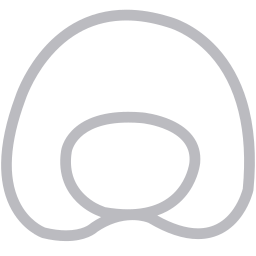


[114] A stylized walking figure with a red dot for a head.


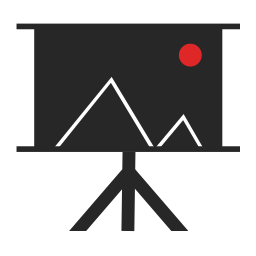


[25] A simple line drawing of an envelope with a folded flap.


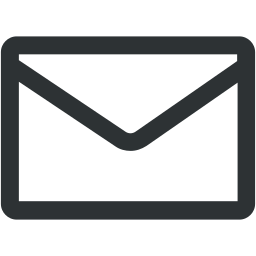


[759] The image features a single black symbol consisting of overlapping letters and lines against a white


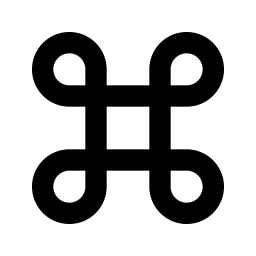


[281] A black and white illustration of a calendar icon with a blank page containing five black dots repre


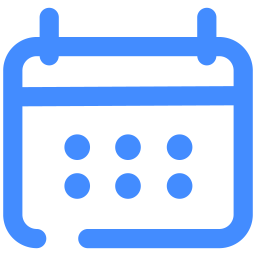


[250] A simple line drawing of a camera with black lines on a white background.


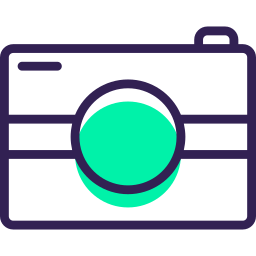

In [29]:
# Render a sample of generated SVGs inline for visual QA
from IPython.display import SVG, display, HTML
import random as rnd

sample_indices = rnd.sample(range(len(submission_df)), min(6, len(submission_df)))

for idx in sample_indices:
    row = submission_df.iloc[idx]
    prompt = test_df.iloc[idx]["prompt"]
    print(f"\n[{idx}] {prompt[:100]}")
    try:
        display(SVG(data=row["svg"]))
    except Exception as e:
        print(f"  Could not render: {e}")

## 11. Save Model Weights for Report Submission

Upload the adapter to HuggingFace Hub or Google Drive and include the link in your report.

In [30]:
# Option A: Push to HuggingFace Hub (recommended for easy sharing)
# Uncomment and fill in your HF token and repo name

# from huggingface_hub import login
# login(token="YOUR_HF_TOKEN_HERE")
# model.push_to_hub("your-username/qwen-svg-lora")
# tokenizer.push_to_hub("your-username/qwen-svg-lora")
# print("Pushed to HuggingFace Hub")

# Option B: Zip the adapter folder for manual upload
import shutil
zip_path = "/kaggle/working/svg_lora_adapter"
shutil.make_archive(zip_path, 'zip', adapter_path)
print(f"Adapter zipped: {zip_path}.zip")
print("Upload this to Google Drive and include the link in your report.")

Adapter zipped: /kaggle/working/svg_lora_adapter.zip
Upload this to Google Drive and include the link in your report.


In [33]:
import re
import xml.etree.ElementTree as ET

def clean_svg(svg_text):
    """Remove duplicate attributes by parsing and re-serializing."""
    if not svg_text or not isinstance(svg_text, str):
        return fallback_svg()
    try:
        # Parse and re-serialize to eliminate duplicate attributes
        ET.register_namespace('', 'http://www.w3.org/2000/svg')
        root = ET.fromstring(svg_text)
        # Force correct dimensions
        root.set('width', '256')
        root.set('height', '256')
        if 'viewBox' not in root.attrib:
            root.set('viewBox', '0 0 256 256')
        cleaned = ET.tostring(root, encoding='unicode')
        return cleaned
    except ET.ParseError:
        return fallback_svg()

print("Cleaning SVGs...")
submission_df = pd.read_csv(CONFIG["submission_path"])
submission_df["svg"] = submission_df["svg"].apply(clean_svg)

# Validate
validity = submission_df["svg"].apply(is_valid_svg)
print(f"Valid: {validity.sum()}/1000 ({validity.mean()*100:.1f}%)")

submission_df.to_csv(CONFIG["submission_path"], index=False)
print("Saved clean submission!")

Cleaning SVGs...
Valid: 1000/1000 (100.0%)
Saved clean submission!


## Run Summary

Print a final summary of this run for reproducibility logging.

In [32]:
print("=" * 60)
print("RUN SUMMARY")
print("=" * 60)
print(f"Model:              {CONFIG['model_name']}")
print(f"LoRA r / alpha:     {CONFIG['lora_r']} / {CONFIG['lora_alpha']}")
print(f"Train samples:      {len(train_ds):,}")
print(f"Epochs:             {CONFIG['num_train_epochs']}")
print(f"Learning rate:      {CONFIG['learning_rate']}")
print(f"Batch size (eff):   {CONFIG['per_device_train_batch_size'] * CONFIG['gradient_accumulation_steps']}")
print(f"Test rows:          {len(submission_df):,}")
print(f"Valid SVG rate:     {valid_rate:.1f}%")
# print(f"Fallback count:     {invalid_count}")
print(f"Random seed:        {SEED}")
print("=" * 60)
print("AI Tooling: Claude (Anthropic) used for code scaffolding and debugging.")

RUN SUMMARY
Model:              Qwen/Qwen2.5-Coder-1.5B-Instruct
LoRA r / alpha:     32 / 64
Train samples:      4,900
Epochs:             2
Learning rate:      0.0002
Batch size (eff):   16
Test rows:          1,000
Valid SVG rate:     99.4%
Random seed:        42
AI Tooling: Claude (Anthropic) used for code scaffolding and debugging.
